In [17]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

##exo a)

#données  
D=np.array([0.05,0.1,0.2,0.4,0.6,0.7,0.8,0.84])
C_cell=np.array([3.2,3.7,4,4.4,4.75,4.9,4.5,0.5])
S=np.array([0.012,0.028,0.05,0.1,0.15,0.176,0.8,9])
S_in=10
mu=D

#Linéarisation de la relation de Monod, on prend les points ou la croissance est limitée par le substrat (1 à 6)
x_fit = 1/S[:6]
y_fit = 1/mu[:6]

pente, intercept = np.polyfit(x_fit, y_fit, 1)

# Affichage des données 
mu_max=1/intercept
K_S=pente*mu_max

print("mu_max =", mu_max)
print("K_S =", K_S)

##exo b) 

r_s=D*(S_in-S)

#Linéarisation 

x_fit = D[1:]
y_fit = r_s[1:]/C_cell[1:]

pente, intercept = np.polyfit(x_fit, y_fit, 1)

# Affichage des données 
m=intercept
Y_xs= 1/pente

print("m =", m)
print("Y_x/s =", Y_xs)

##exo c)

D_max=mu_max/(1+K_S/S_in)
print("D_max =", D_max)
D_opt=mu_max*(1-(K_S/(K_S+S_in))**(1/2))
print("D_opt =", D_opt)




mu_max = 3.7175477079636114
K_S = 0.897882481899785
m = 0.10913424334633563
Y_x/s = 0.5301278298989426
D_max = 3.411256924579669
D_opt = 2.650471984437229


mu_max ajusté = 0.998
K_S ajusté = 0.129
m = 0.10536100472206678
Y_x/s = 0.5265095550370632
D_max = 0.9848210010394914
D_opt = 0.8850183122321077


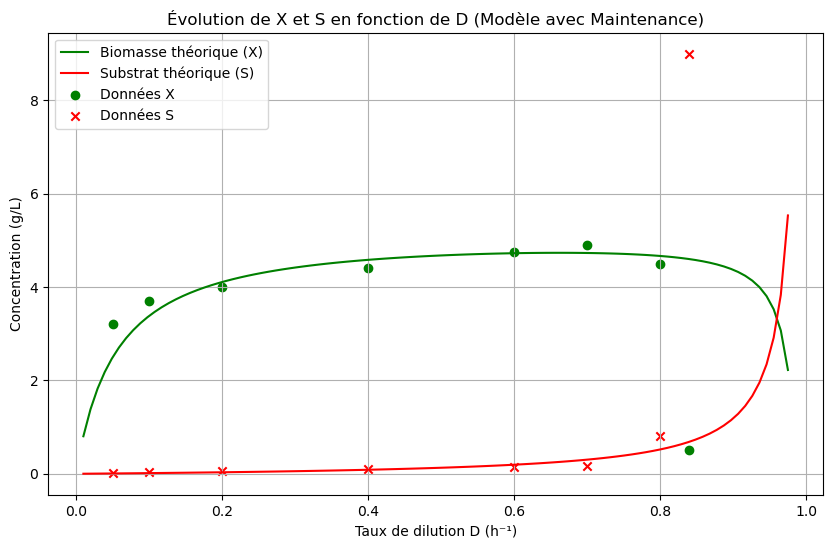

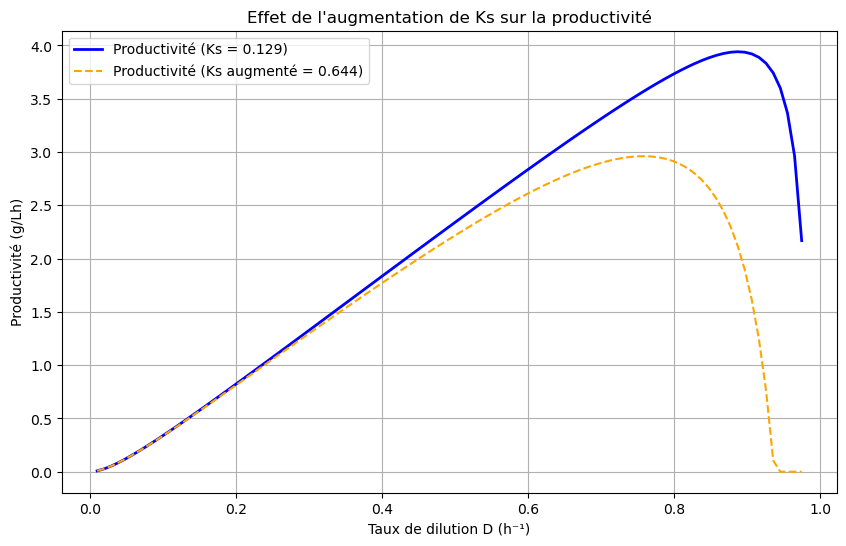

Productivité maximale initiale = 3.941 g/Lh
Taux de dilution à la productivité maximale initiale = 0.887 h⁻¹


In [18]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

# Fonction de Monod
def monod(S, mu_max, Ks):
    return (mu_max * S) / (Ks + S)

# Ajustement direct sur les données (S, D)
# On exclut le dernier point de wash-out pour la stabilité
popt, _ = curve_fit(monod, S[:-1], D[:-1], p0=[1.0, 0.2])

mu_max, K_S = popt

print(f"mu_max ajusté = {mu_max:.3f}")
print(f"K_S ajusté = {K_S:.3f}")
##exo b) 

r_s=D*(S_in-S)

#Linéarisation 

x_fit = D[1:-1]
y_fit = r_s[1:-1]/C_cell[1:-1]

pente, intercept = np.polyfit(x_fit, y_fit, 1)

# Affichage des données 
m=intercept
Y_xs= 1/pente

print("m =", m)
print("Y_x/s =", Y_xs)

##exo c)

D_max=mu_max/(1+K_S/S_in)
print("D_max =", D_max)
D_opt=mu_max*(1-(K_S/(K_S+S_in))**(1/2))
print("D_opt =", D_opt)

##exo d)

D_sim = np.linspace(0.01, D_max - 0.01, 100)

S_theo = (K_S * D_sim) / (mu_max - D_sim)
C_cell_theo = (D_sim * (S_in - S_theo)) / ((D_sim/Y_xs) + m)

# --- Visualisation ---
plt.figure(figsize=(10, 6))
plt.plot(D_sim, C_cell_theo, label="Biomasse théorique (X)", color="green")
plt.plot(D_sim, S_theo, label="Substrat théorique (S)", color="red")

# Ajout des points expérimentaux pour comparer
plt.scatter(D, C_cell, color="green", marker="o", label="Données X")
plt.scatter(D, S, color="red", marker="x", label="Données S")

plt.xlabel("Taux de dilution D (h⁻¹)")
plt.ylabel("Concentration (g/L)")
plt.title("Évolution de X et S en fonction de D (Modèle avec Maintenance)")
plt.legend()
plt.grid(True)
plt.show()

##exo e)

# 1. Productivité Ks actuel (0.129)
Pr_initial = D_sim * C_cell_theo

# 2. Simulation avec un Ks augmenté 5*
Ks_high = K_S * 5  
S_high = (Ks_high * D_sim) / (mu_max - D_sim)
X_high = (D_sim * (S_in - S_high)) / ( (D_sim / Y_xs) + m )

# On s'assure de ne pas garder de valeurs de X négatives 
X_high = np.maximum(X_high, 0)
Pr_high = D_sim * X_high

# --- Graphique de productivité ---
plt.figure(figsize=(10, 6))
plt.plot(D_sim, Pr_initial, label=f"Productivité (Ks = {K_S:.3f})", color="blue", linewidth=2)
plt.plot(D_sim, Pr_high, label=f"Productivité (Ks augmenté = {Ks_high:.3f})", color="orange", linestyle="--")

plt.xlabel("Taux de dilution D (h⁻¹)")
plt.ylabel("Productivité (g/Lh)")
plt.title("Effet de l'augmentation de Ks sur la productivité")
plt.legend()
plt.grid(True)
plt.show()

##exo f)

max_productivity_initial = np.max(Pr_initial)
print(f"Productivité maximale initiale = {max_productivity_initial:.3f} g/Lh")
dilution_at_max_initial = D_sim[np.argmax(Pr_initial)]
print(f"Taux de dilution à la productivité maximale initiale = {dilution_at_max_initial:.3f} h⁻¹")



mu_max = 0.9057187984474928
Ks = 0.10614014069822784
Yxs = 0.5224828894606299
m = 0.09047980415914778


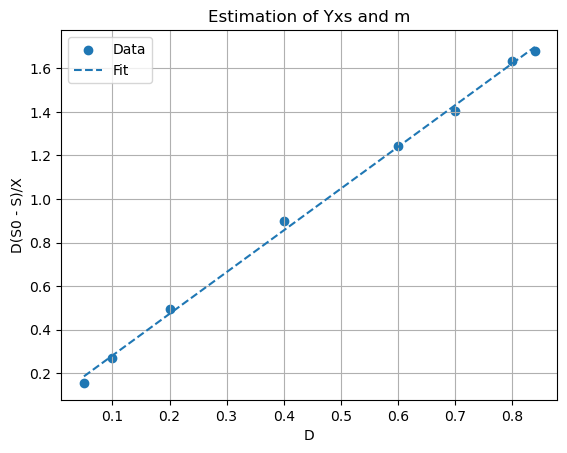

Dmax = 0.8962064505716594
Dopt (theoretical) = 0.8128990145190947


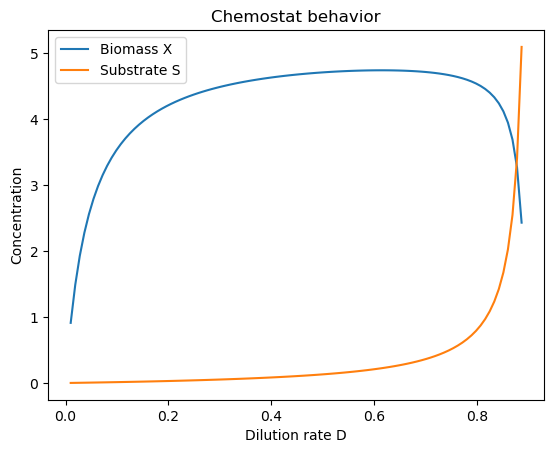

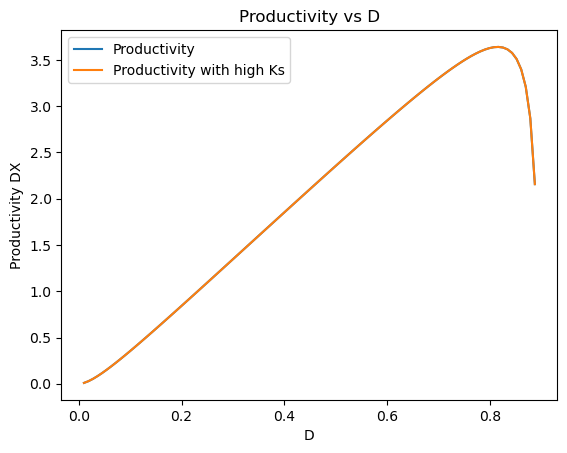

Dopt = 0.8163559508282908
Max productivity = 3.640905299981525


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

D = np.array([0.05, 0.1, 0.2, 0.4, 0.6, 0.7, 0.8, 0.84])
X = np.array([3.2, 3.7, 4.0, 4.4, 4.75, 4.9, 4.5, 0.5])
S = np.array([0.012, 0.028, 0.05, 0.1, 0.15, 0.176, 0.8, 9.0])

S0 = 10  # feed substrate

# -----------------------------
# Part (a)

def monod(S, mu_max, Ks):
    return mu_max * S / (Ks + S)

params, _ = curve_fit(monod, S, D, bounds=(0, np.inf))
mu_max, Ks = params



print("mu_max =", mu_max)
print("Ks =", Ks)

# -----------------------------
# (b)  


# Linearization
y = D * (S0 - S) / X
x = D

# Linear fit
coeffs = np.polyfit(x, y, 1)
slope, intercept = coeffs

# Extract parameters
Yxs = 1 / slope
m = intercept

print("Yxs =", Yxs)
print("m =", m)

# Plot for report
plt.figure()
plt.scatter(x, y, label="Data")

x_fit = np.linspace(min(x), max(x), 100)
y_fit = slope * x_fit + intercept
plt.plot(x_fit, y_fit, '--', label="Fit")

plt.xlabel("D")
plt.ylabel("D(S0 - S)/X")
plt.title("Estimation of Yxs and m")
plt.legend()
plt.grid()
plt.show()


# -----------------------------
# Part (c)

D_max = mu_max * S0 / (Ks + S0)
print("Dmax =", D_max)

D_opt_theoretical = mu_max * (1 - np.sqrt(Ks / (Ks + S0)))
print("Dopt (theoretical) =", D_opt_theoretical)

# -----------------------------
# Part (d,e)

D_range = np.linspace(0.01, D_max*0.99, 100)

S_model = Ks * D_range / (mu_max - D_range)
X_model = (D_range * (S0 - S_model)) / ((D_range/Yxs) + m)
P = D_range * X_model

Ks_high = 10 * Ks
S_high = Ks_high * D_range / (mu_max - D_range)
X_high = (D_range * (S0 - S_model)) / ((D_range/Yxs) + m)
X_high = np.maximum(X_high, 0)
P_high = D_range * X_high

# -----------------------------
# Plot
# -----------------------------
plt.figure()
plt.plot(D_range, X_model, label="Biomass X")
plt.plot(D_range, S_model, label="Substrate S")
plt.xlabel("Dilution rate D")
plt.ylabel("Concentration")
plt.legend()
plt.title("Chemostat behavior")
plt.show()

# Productivity
plt.figure()
plt.plot(D_range, P, label="Productivity")
plt.plot(D_range, P_high, label="Productivity with high Ks")
plt.xlabel("D")
plt.ylabel("Productivity DX")
plt.legend()
plt.title("Productivity vs D")
plt.show()

# -----------------------------
# Part (f): Optimal D
# -----------------------------
D_opt = D_range[np.argmax(P)]
P_max = np.max(P)

print("Dopt =", D_opt)
print("Max productivity =", P_max)